In [ ]:
# Paths - edit for your environment
SUPREMO_DIR = "/pollard/home/szhang20/akita_variant_scoring"
AKITA_DIR = "/pollard/home/szhang20/akita"
PROJECT_DIR = "/pollard/home/szhang20/alu"
DATA_DIR = "/pollard/data/projects/shzhang"
POLLARD_DATA = "/pollard/data"


In [20]:
%load_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import numpy as np
import pandas as pd
import sys, os, math
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
import pysam
from Bio.Seq import Seq
from Bio import pairwise2
from Bio import motifs

# paths
sys.path.append(f'{SUPREMO_DIR}/')
sys.path.insert(0, f'{SUPREMO_DIR}/scripts/')

import akita_utils_forplotting as utils
import akita_utils_scoring as scoring_utils

import plotting_utils
import get_Akita_scores_utils as akita
import scoring
from cooltools.lib.plotting import gridspec_inches

# constants
MB       = 1_048_576
bin_size = akita.bin_size            # 2048
tlc      = akita.target_length_cropped  # 448



In [22]:
PLOT_RC = {
    'font.family'        : 'sans-serif',
    'font.sans-serif'    : ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size'          : 7,
    'axes.titlesize'     : 8,
    'axes.labelsize'     : 7,
    'xtick.labelsize'    : 6,
    'ytick.labelsize'    : 6,
    'legend.fontsize'    : 6,
    'axes.linewidth'     : 0.6,
    'axes.edgecolor'     : 'black',
    'axes.facecolor'     : 'white',
    'figure.facecolor'   : 'white',
    'axes.grid'          : False,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.spines.left'   : True,
    'axes.spines.bottom' : True,
    'xtick.direction'    : 'out',
    'ytick.direction'    : 'out',
    'xtick.major.size'   : 2.5,
    'ytick.major.size'   : 2.5,
    'xtick.major.width'  : 0.5,
    'ytick.major.width'  : 0.5,
    'lines.linewidth'    : 0.9,
    'figure.dpi'         : 150,
    'savefig.dpi'        : 600,
    'savefig.bbox'       : 'tight',
    'pdf.fonttype'       : 42,
    'ps.fonttype'        : 42,
    'svg.fonttype'       : 'none',
    'figure.titlesize'   : 8,
}

matplotlib.rcParams.update(PLOT_RC)

rdbu_modified = ['#1a1f6b', '#3a62b0', '#7a9fd4', '#c4cfe8', '#f7f7f7',
                 '#f2b49a', '#d4765f', '#a8303f', '#5c1020']
cmap_pred = mcolors.LinearSegmentedColormap.from_list('cmap_pred', rdbu_modified, N=256)

prgn_modified = ['#3b2255', '#6b3d7a', '#9b6aaa', '#c4a3c8', '#e8dff0', '#f7f7f7',
                 '#ccddb8', '#8aaf72', '#4e8a4e', '#2a5c35', '#0f3320']


In [28]:
def save_figures_to_pdf(path, figures):
    with PdfPages(path) as pdf:
        for f in figures:
            pdf.savefig(f, bbox_inches='tight')


In [29]:
def plot_blanks(REF_map, clean_map, seq_len, cmap_pred=cmap_pred, cmap_diff=cmap_diff, scale=1):

    from cooltools.lib.plotting import gridspec_inches


    panels = [(REF_map, f"REF", cmap_pred, -2, 2), (clean_map,  f"Post CTCF removal", cmap_pred, -2, 2)]
    


    ############# figure geometry
    lw     = 0.5 * scale
    pw     = 2   * scale
    lines  = [seq_len/2]
    row_heights = []
    
    for _ in panels:
        row_heights += [pw, .1]
    row_heights = row_heights[:-1]  
    fig, gs = gridspec_inches([pw * 2], row_heights)

    ############# triangle maps
    for ri, (mat, title, cm, vn, vx) in enumerate(panels):
        ax_i = ri * 2
        ax = plt.subplot(gs[ax_i, 0])
        plotting_utils.pcolormesh_45deg(plt, mat, lines, lw, cmap=cm, vmax=vx, vmin=vn)
        ax.annotate(title,
            xy=(0, 0.9), xycoords='axes fraction',
            xytext=(0, 4 * scale), textcoords='offset points',
            ha='left', va='bottom', annotation_clip=False)

    ############# suptitle
    sup = ''
    fig.suptitle(sup, y=1.02)

    plt.show()


In [30]:
CTCF_pwm=f'{DATA_DIR}/alus/data/CTCF.jaspar'

In [31]:
motif_dict={}
with open(CTCF_pwm) as handle:
    records = motifs.parse(handle, "jaspar")
for motif in records:
    print(f"Motif Name: {motif.name}")
    print(f"Matrix ID: {motif.matrix_id}")

    
    ctcf_counts = np.array([
        list(motif.counts['A']),
        list(motif.counts['C']),
        list(motif.counts['G']),
        list(motif.counts['T'])
    ])
    
    
    motif_dict[motif.matrix_id]=ctcf_counts
# Get the PWM
ctcf_pwm = list(motif_dict.values())[0]

# Normalize to frequencies (0-1)
ctcf_pwm_freq = ctcf_pwm.astype(float) / np.sum(ctcf_pwm, axis=0)


Motif Name: CTCF
Matrix ID: MA0139.1
Motif Name: CTCF
Matrix ID: MA0139.2


In [32]:
ctcf_pwm_freq

array([[0.09529025, 0.18291347, 0.30777656, 0.06133625, 0.00876232,
        0.81489595, 0.04381161, 0.11732456, 0.93311404, 0.00548847,
        0.36553238, 0.05927552, 0.01318681, 0.06153846, 0.11441144,
        0.40924092, 0.09030837, 0.12885463, 0.44273128],
       [0.31872946, 0.15881709, 0.05366922, 0.8762322 , 0.9890471 ,
        0.01423877, 0.57831325, 0.4747807 , 0.0120614 , 0.        ,
        0.00329308, 0.01317234, 0.        , 0.00879121, 0.80638064,
        0.01430143, 0.530837  , 0.35462555, 0.19933921],
       [0.08324206, 0.45345016, 0.49178532, 0.0230011 , 0.        ,
        0.07119387, 0.36582694, 0.05263158, 0.03508772, 0.99121844,
        0.62129528, 0.5532382 , 0.97802198, 0.85164835, 0.00550055,
        0.55775578, 0.33810573, 0.08039648, 0.29295154],
       [0.50273823, 0.20481928, 0.14676889, 0.03943045, 0.00219058,
        0.09967141, 0.01204819, 0.35526316, 0.01973684, 0.00329308,
        0.00987925, 0.37431394, 0.00879121, 0.07802198, 0.07370737,
        0.018

In [33]:
motif_dict['MA0139.1']

array([[ 87., 167., 281.,  56.,   8., 744.,  40., 107., 851.,   5., 333.,
         54.,  12.,  56., 104., 372.,  82., 117., 402.],
       [291., 145.,  49., 800., 903.,  13., 528., 433.,  11.,   0.,   3.,
         12.,   0.,   8., 733.,  13., 482., 322., 181.],
       [ 76., 414., 449.,  21.,   0.,  65., 334.,  48.,  32., 903., 566.,
        504., 890., 775.,   5., 507., 307.,  73., 266.],
       [459., 187., 134.,  36.,   2.,  91.,  11., 324.,  18.,   3.,   9.,
        341.,   8.,  71.,  67.,  17.,  37., 396.,  59.]])

In [34]:
def generate_blank_sequence(length, gc_content=0.41, seed_i=0):
    """Generate a random DNA sequence with specified GC content."""
    
    rng = np.random.default_rng(seed=seed_i)
    
    nucleotides = np.array(['A', 'C', 'G', 'T'])
    probs = np.array([(1 - gc_content) / 2, gc_content / 2, gc_content / 2, (1 - gc_content) / 2])
    return ''.join(rng.choice(nucleotides, size=length, p=probs))


def score_motif_pwm(seq, pwm, threshold=0.8):
    """Score sequence against PWM."""
    motif_len = pwm.shape[1]
    matches = []
    
    for i in range(len(seq) - motif_len + 1):
        subseq = seq[i:i+motif_len]
        score = 0.0
        
        for j, base in enumerate(subseq):
            base_idx = {'A': 0, 'C': 1, 'G': 2, 'T': 3}[base]
            score += pwm[base_idx, j]
        
        max_score = np.sum(np.max(pwm, axis=0))
        norm_score = score / max_score
        
        if norm_score >= threshold:
            matches.append((i, norm_score))
    
    return matches


def remove_ctcf_motifs_pwm(seq, pwm, threshold=0.8, gc_content=0.41, seed_i=0, max_iterations=100):
    """Remove CTCF-like motifs using PWM scoring."""
    seq = list(seq)
    motif_len = pwm.shape[1]
    iteration = 0
    
    while iteration < max_iterations:
        matches = score_motif_pwm(''.join(seq), pwm, threshold)
        
        if not matches:
            break
        
        for pos, score in reversed(matches):
            replacement = generate_blank_sequence(motif_len, gc_content, seed_i)
            for i, char in enumerate(replacement):
                seq[pos + i] = char
        
        iteration += 1
    
    return ''.join(seq)


In [35]:
def get_pwm_consensus(pwm):
    """Highest-frequency base at each PWM position → consensus string."""
    bases = ['A', 'C', 'G', 'T']
    return ''.join(bases[np.argmax(pwm[:, j])] for j in range(pwm.shape[1]))


def insert_inverted_ctcf_pair(seq, pwm, distance_from_center, num_CTCF=1):
    """
    Insert a convergent (→ ←) CTCF pair into seq by overwriting bases.

    The forward consensus is centered at (center - distance_from_center)
    and its reverse complement is centered at (center + distance_from_center).
    Sequence length is preserved.

    Parameters
    ----------
    seq                  : str, length MB
    pwm                  : np.ndarray [4, motif_len], frequency matrix
    distance_from_center : int, bp from sequence center to each motif midpoint

    Returns
    -------
    seq_with_ctcf        : str, same length as input
    left_start           : int, 0-based start of forward motif
    right_start          : int, 0-based start of reverse-complement motif
    """
    seq_arr   = list(seq)
    motif_len = pwm.shape[1]
    
    #consensus = get_pwm_consensus(pwm)*num_CTCF
    CTCF_motif='TGGCCACTAGGTGGCGCCA' #use super motif as identified in Laura paper 
    consensus = CTCF_motif*num_CTCF

    rev_cons  = str(Seq(consensus).reverse_complement())

    center      = len(seq_arr) // 2
    half_m      = motif_len // 2

    left_start  = center - distance_from_center - half_m
    right_start = center + distance_from_center - half_m

    for i, base in enumerate(consensus):
        seq_arr[left_start + i] = base
    for i, base in enumerate(rev_cons):
        seq_arr[right_start + i] = base

    return ''.join(seq_arr), left_start, right_start


In [12]:
# # Usage
# MB=1048576


# for gc_val in [0.45,0.475, 0.5, 0.525, 0.55, 0.575, 0.60]:
#     print(f'gc at {gc_val}')
    
#     for i in range (0,1):
#         print(f'    iteration {i}')
        
    
#         blank_seq = generate_blank_sequence(length=MB, gc_content=gc_val, seed_i=i)
#         before_matches = score_motif_pwm(blank_seq,motif_dict['MA0139.1'], threshold=0.8)

#         clean_seq = remove_ctcf_motifs_pwm(blank_seq, ctcf_pwm_freq, threshold=0.8, gc_content=gc_val, seed_i=i)
#         after_matches = score_motif_pwm(clean_seq, ctcf_pwm_freq, threshold=0.8)

#         print(f"Matches before: {len(before_matches)}")
#         print(f"Matches after: {len(after_matches)}")
#         print(f"GC content: {(clean_seq.count('G') + clean_seq.count('C')) / len(clean_seq):.4f}")

#         blank_pred = akita.vector_from_seq(blank_seq)
#         blank_map = akita.map_from_vector(blank_pred)

#         clean_pred = akita.vector_from_seq(clean_seq)
#         clean_map = akita.map_from_vector(clean_pred)

#         plot_blanks(blank_map, clean_map, MB, cmap_pred=cmap_pred, cmap_diff=cmap_diff, scale=1)


In [13]:
#generate blanks 
gc_val = 0.5
seed_i = 0

blank_seq = generate_blank_sequence(length=MB, gc_content=gc_val, seed_i=seed_i)


dist=50 kb | fwd @ 474279–474298  rev @ 574279–574298
  fwd inserted: TGGCCACTAGGTGGCGCCA
  rev inserted: TGGCGCCACCTAGTGGCCA
dist=100 kb | fwd @ 424279–424298  rev @ 624279–624298
  fwd inserted: TGGCCACTAGGTGGCGCCA
  rev inserted: TGGCGCCACCTAGTGGCCA
dist=200 kb | fwd @ 324279–324298  rev @ 724279–724298
  fwd inserted: TGGCCACTAGGTGGCGCCA
  rev inserted: TGGCGCCACCTAGTGGCCA
dist=250 kb | fwd @ 274279–274298  rev @ 774279–774298
  fwd inserted: TGGCCACTAGGTGGCGCCA
  rev inserted: TGGCGCCACCTAGTGGCCA
dist=300 kb | fwd @ 224279–224298  rev @ 824279–824298
  fwd inserted: TGGCCACTAGGTGGCGCCA
  rev inserted: TGGCGCCACCTAGTGGCCA


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 35 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'F', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'plus', 'plusminus', 'r', 'space', 't', 'three', 'two', 'v', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 14, 16, 19, 20, 21, 22, 24, 38, 41, 55, 68, 69, 70, 71, 72, 73, 74, 76, 78, 79, 80, 81, 82, 83, 85, 87, 89, 115, 3228]
INFO:fontTools.subset:Closed glyph list over 'MATH': 41 glyphs after
INFO:fontTools.subset

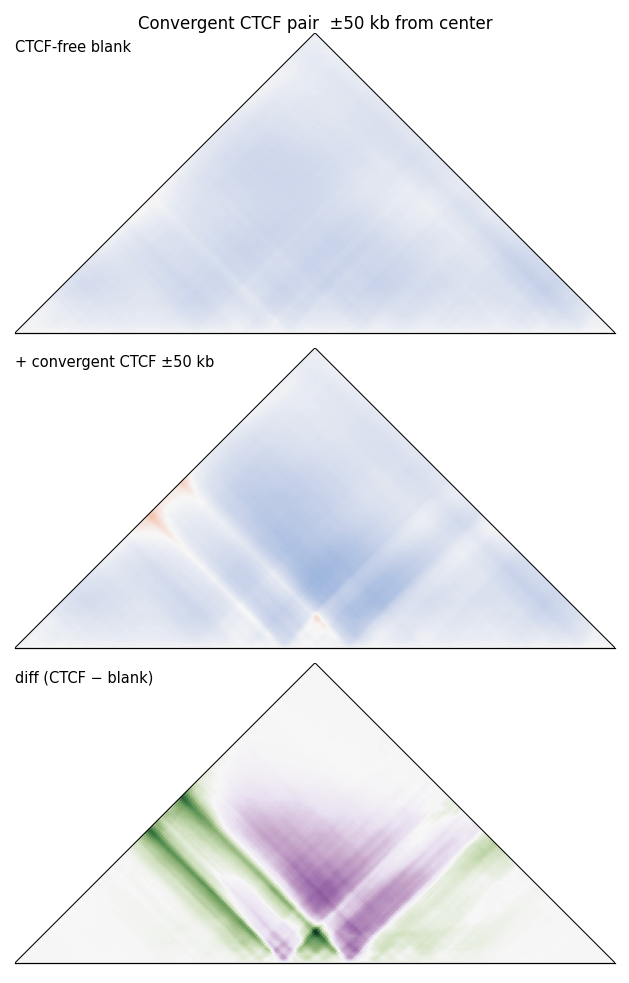

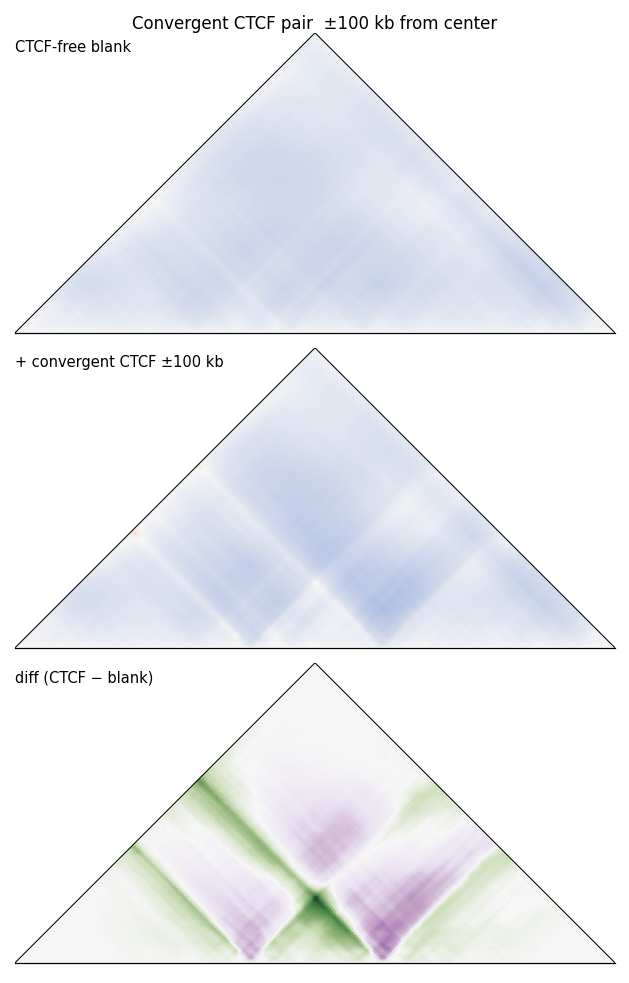

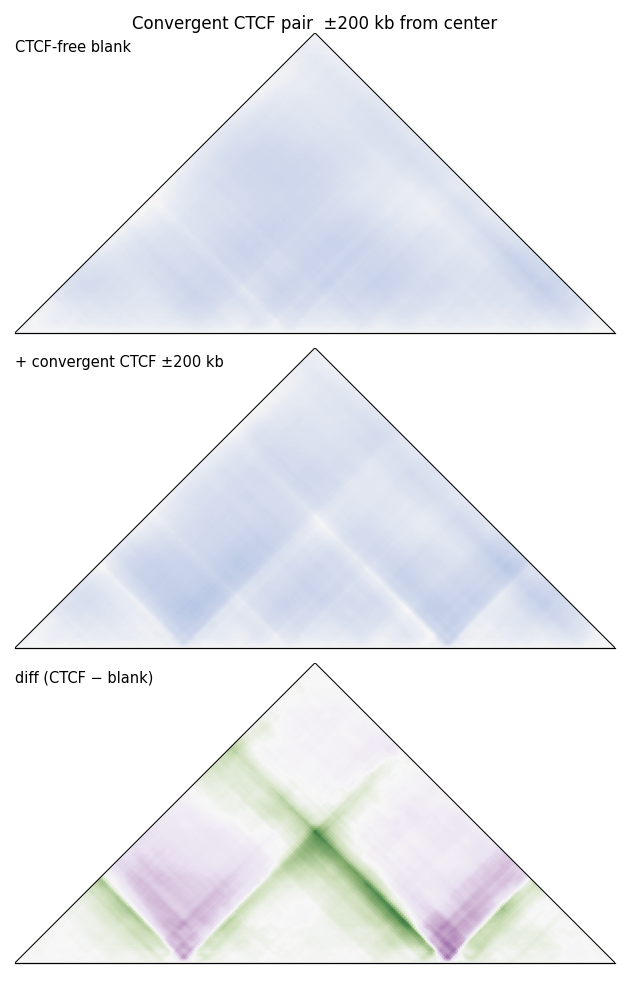

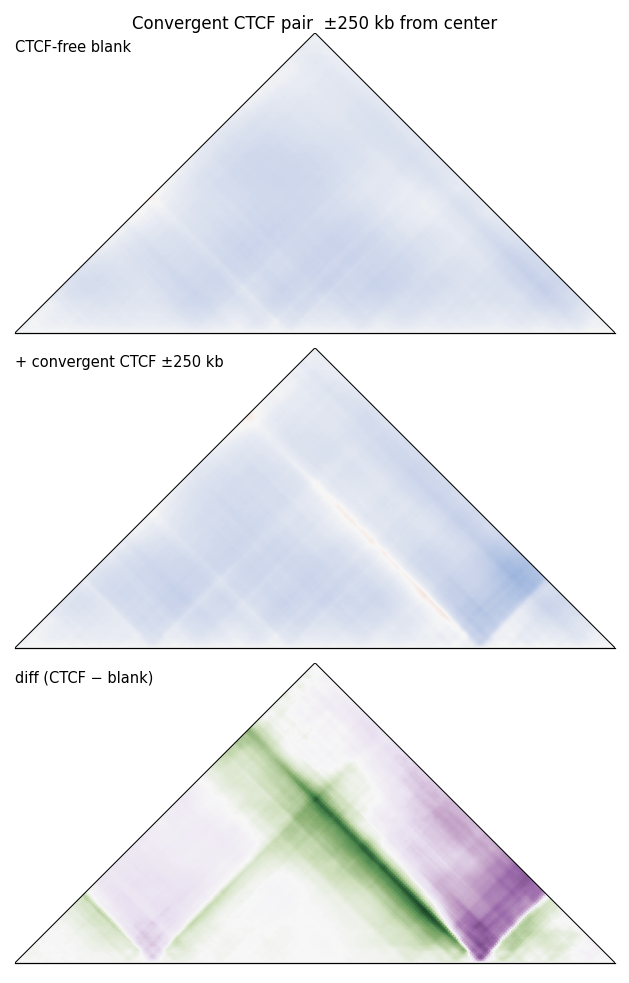

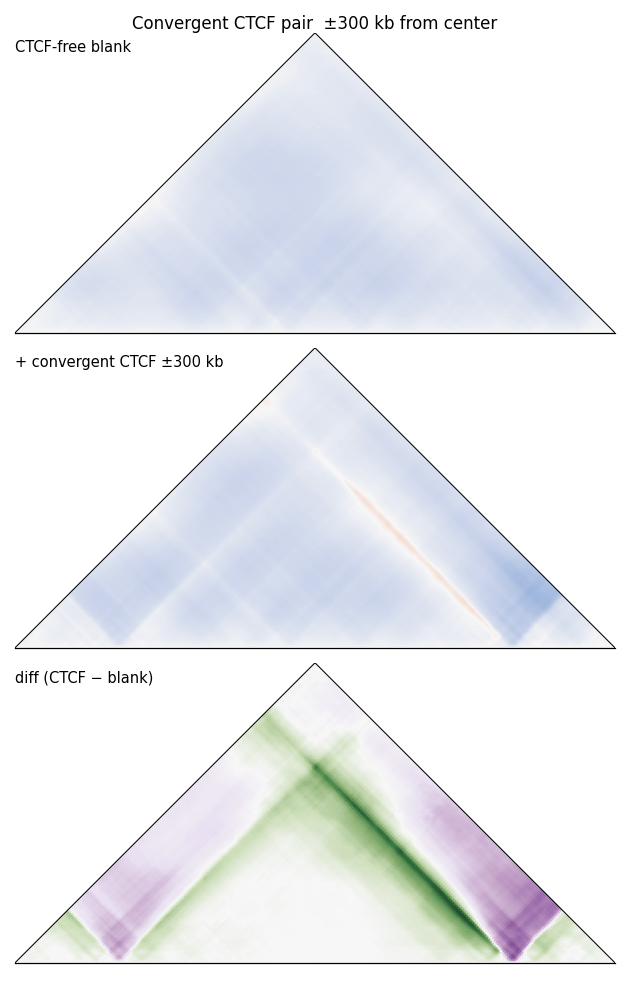

In [44]:
import matplotlib.backends.backend_pdf as pdf_backend

# --- insert convergent CTCF pair at varying distances ---
distances = [50_000, 100_000, 200_000, 250_000, 300_000]   # bp from center


with plt.rc_context(PLOT_RC), \
     pdf_backend.PdfPages(f'{PROJECT_DIR}/figs/paper_figs/blank_ctcf.pdf') as pdf:

    for dist in distances:
        ctcf_seq, left_start, right_start = insert_inverted_ctcf_pair(
            clean_seq, ctcf_pwm_freq, distance_from_center=dist, num_CTCF=50)

        # confirm the sites landed where expected
        consensus  = get_pwm_consensus(ctcf_pwm_freq)
        motif_len  = ctcf_pwm_freq.shape[1]
        print(f"dist={dist//1000} kb | "
              f"fwd @ {left_start}–{left_start+motif_len}  "
              f"rev @ {right_start}–{right_start+motif_len}")
        print(f"  fwd inserted: {ctcf_seq[left_start:left_start+motif_len]}")
        print(f"  rev inserted: {ctcf_seq[right_start:right_start+motif_len]}")

        clean_pred = akita.vector_from_seq(clean_seq)
        clean_map  = akita.map_from_vector(clean_pred)

        ctcf_pred  = akita.vector_from_seq(ctcf_seq)
        ctcf_map   = akita.map_from_vector(ctcf_pred)

        panels = [
            (clean_map, "CTCF-free blank",          cmap_pred, -2, 2),
            (ctcf_map,  f"+ convergent CTCF ±{dist//1000} kb", cmap_pred, -2, 2),
            (ctcf_map - clean_map, "diff (CTCF − blank)",       cmap_diff, -0.5, 0.5),
        ]

        from cooltools.lib.plotting import gridspec_inches
        lw, pw = 0.5, 2
        row_heights = []
        for _ in panels:
            row_heights += [pw, .1]
        row_heights = row_heights[:-1]
        fig, gs = gridspec_inches([pw * 2], row_heights)

        lines = [MB / 2]
        for ri, (mat, title, cm, vn, vx) in enumerate(panels):
            ax = plt.subplot(gs[ri * 2, 0])
            plotting_utils.pcolormesh_45deg(plt, mat, lines, lw, cmap=cm, vmax=vx, vmin=vn)
            ax.annotate(title, xy=(0, 0.9), xycoords='axes fraction',
                        xytext=(0, 4), textcoords='offset points',
                        ha='left', va='bottom', annotation_clip=False)

        fig.suptitle(f'Convergent CTCF pair  ±{dist//1000} kb from center', y=1.02)
        pdf.savefig(fig)


In [37]:
def insert_all_alus_with_ctcf(clean_seq, alu_dfam, ctcf_pwm, alu_distance_from_center,
                               ctcf_distance_from_center, revcomp_alu=False, num_CTCF=10):
    """
    For every Alu family in alu_dfam, build a sequence containing:
      - the Alu consensus inserted at center + alu_distance_from_center
      - a convergent CTCF pair at ±ctcf_distance_from_center

    Alu insertion follows alu_ins_grad.py: insert consensus, then trim
    ceil(ins_len/2) from the left and floor(ins_len/2) from the right
    so the sequence stays exactly MB bp. CTCF is written on top after.

    Parameters
    ----------
    clean_seq                 : str, CTCF-free background of length MB
    alu_dfam                  : pd.DataFrame with columns AluName, Consensus_seq
    ctcf_pwm                  : np.ndarray [4, motif_len], frequency matrix
    alu_distance_from_center  : int, bp from center to the Alu insertion point
                                (positive = right of center, 0 = at center)
    ctcf_distance_from_center : int, bp from center to midpoint of each CTCF site
    revcomp_alu               : bool, reverse-complement each consensus before inserting

    Returns
    -------
    list of dicts, one per Alu family:
        alu_name         : str
        seq              : str, final MB-length sequence
        alu_insert_pos   : int, 0-based insertion index
        left_ctcf_start  : int, 0-based start of forward CTCF motif
        right_ctcf_start : int, 0-based start of rev-comp CTCF motif
        pred             : np.ndarray, Akita output vector
        map              : np.ndarray [tlc, tlc], predicted Hi-C matrix
    """
    center  = len(clean_seq) // 2
    ins_pos = center + alu_distance_from_center

    results = []
    for _, row in alu_dfam.iterrows():
        alu_name      = row['AluName']
        consensus_seq = row['Consensus_seq'].upper()

        if revcomp_alu:
            consensus_seq = str(Seq(consensus_seq).reverse_complement())

        # 1. Insert Alu and crop back to MB
        seq     = clean_seq[:ins_pos] + consensus_seq + clean_seq[ins_pos:]
        ins_len = len(consensus_seq)
        trim    = ins_len / 2
        if trim == 0.5:
            seq = seq[1:]
        else:
            seq = seq[math.ceil(trim) : -math.floor(trim)]

        # 2. Overwrite bases with convergent CTCF pair
        seq, left_ctcf, right_ctcf = insert_inverted_ctcf_pair(
            seq, ctcf_pwm, ctcf_distance_from_center,  num_CTCF=num_CTCF)

        pred = akita.vector_from_seq(seq)
        mat  = akita.map_from_vector(pred)

        results.append(dict(
            alu_name=alu_name,
            seq=seq,
            alu_insert_pos=ins_pos,
            left_ctcf_start=left_ctcf,
            right_ctcf_start=right_ctcf,
            pred=pred,
            map=mat,
        ))

    return results


In [38]:
def insert_two_alus_with_ctcf(clean_seq, alu_dfam, ctcf_pwm, alu_distance_from_center, ctcf_distance_from_center,
                              num_CTCF=1, revcomp_left=False, revcomp_right=False):
    """
    For every Alu family in alu_dfam, build a sequence containing:
      - left  Alu centered at center - alu_distance_from_center
      - right Alu centered at center + alu_distance_from_center
      - convergent CTCF pair at ±ctcf_distance_from_center

    revcomp_left / revcomp_right control orientation independently, e.g.:
      revcomp_left=False, revcomp_right=True  → convergent  (→ ←)
      revcomp_left=True,  revcomp_right=False → divergent   (← →)
      revcomp_left=False, revcomp_right=False → tandem fwd  (→ →)
      revcomp_left=True,  revcomp_right=True  → tandem rev  (← ←)

    Both Alus are the same family (same length), so cropping is symmetric:
    trim ins_len bases from each end after the double insertion.

    Parameters
    ----------
    clean_seq                 : str, CTCF-free background of length MB
    alu_dfam                  : pd.DataFrame with columns AluName, Consensus_seq
    ctcf_pwm                  : np.ndarray [4, motif_len], frequency matrix
    alu_distance_from_center  : int, bp from center to each Alu insertion point
    ctcf_distance_from_center : int, bp from center to midpoint of each CTCF site
    revcomp_left              : bool, reverse-complement the left Alu
    revcomp_right             : bool, reverse-complement the right Alu

    Returns
    -------
    list of dicts, one per Alu family:
        alu_name          : str
        seq               : str, final MB-length sequence
        left_alu_pos      : int, 0-based insertion index of left Alu
        right_alu_pos     : int, 0-based insertion index of right Alu (pre-crop coords)
        left_ctcf_start   : int, 0-based start of forward CTCF motif
        right_ctcf_start  : int, 0-based start of rev-comp CTCF motif
        pred              : np.ndarray, Akita output vector
        map               : np.ndarray [tlc, tlc], predicted Hi-C matrix
    """
    center        = len(clean_seq) // 2
    left_ins_pos  = center - alu_distance_from_center
    right_ins_pos = center + alu_distance_from_center

    results = []
    for _, row in alu_dfam.iterrows():
        alu_name      = row['AluName']
        consensus_seq = row['Consensus_seq'].upper()
        ins_len       = len(consensus_seq)

        left_cons  = str(Seq(consensus_seq).reverse_complement()) if revcomp_left  else consensus_seq
        right_cons = str(Seq(consensus_seq).reverse_complement()) if revcomp_right else consensus_seq

        # Insert left Alu, then right (right pos shifts by ins_len after left insert)
        seq = clean_seq[:left_ins_pos] + left_cons + clean_seq[left_ins_pos:]
        adj_right = right_ins_pos + ins_len
        seq = seq[:adj_right] + right_cons + seq[adj_right:]

        # Crop symmetrically: total added = 2 * ins_len, trim ins_len from each side
        seq = seq[ins_len : -ins_len]

        # Overwrite bases with convergent CTCF pair
        seq, left_ctcf, right_ctcf = insert_inverted_ctcf_pair(
            seq, ctcf_pwm, ctcf_distance_from_center, num_CTCF=num_CTCF)

        pred = akita.vector_from_seq(seq)
        mat  = akita.map_from_vector(pred)

        results.append(dict(
            alu_name=alu_name,
            seq=seq,
            left_alu_pos=left_ins_pos,
            right_alu_pos=right_ins_pos,
            left_ctcf_start=left_ctcf,
            right_ctcf_start=right_ctcf,
            pred=pred,
            map=mat,
        ))



In [39]:
def _insert_ctcf_pair_from_seq(seq, ctcf_seq, distance_from_center):
    """Insert a convergent CTCF pair using a literal sequence string."""
    seq_arr     = list(seq)
    half_m      = len(ctcf_seq) // 2
    rev_seq     = str(Seq(ctcf_seq).reverse_complement())
    center      = len(seq_arr) // 2
    left_start  = center - distance_from_center - half_m
    right_start = center + distance_from_center - half_m
    for i, base in enumerate(ctcf_seq):
        seq_arr[left_start + i] = base
    for i, base in enumerate(rev_seq):
        seq_arr[right_start + i] = base
    return ''.join(seq_arr), left_start, right_start


def insert_two_alus_two_ctcfs(clean_seq, alu_dfam,
                               ctcf_seq_1, ctcf_seq_2,
                               alu_distance_from_center,
                               ctcf_distance_from_center,
                               revcomp_left=False, revcomp_right=False):
    """
    For every Alu family in alu_dfam, build two sequences (one per CTCF) each containing:
      - left  Alu at center - alu_distance_from_center
      - right Alu at center + alu_distance_from_center
      - convergent CTCF pair from ctcf_seq_X at +/-ctcf_distance_from_center

    Alu orientation via revcomp_left / revcomp_right:
      (False, True)  -> convergent  (-> <-)
      (True,  False) -> divergent   (<- ->)
      (False, False) -> tandem fwd  (-> ->)
      (True,  True)  -> tandem rev  (<- <-)

    Returns
    -------
    list of dicts, one per Alu family:
        alu_name : str
        result_1 : dict with seq, pred, map, left_ctcf_start, right_ctcf_start,
                   left_alu_pos, right_alu_pos  (for ctcf_seq_1)
        result_2 : same for ctcf_seq_2
    """
    center        = len(clean_seq) // 2
    left_ins_pos  = center - alu_distance_from_center
    right_ins_pos = center + alu_distance_from_center

    def _build(consensus_seq, ctcf_seq):
        ins_len    = len(consensus_seq)
        left_cons  = str(Seq(consensus_seq).reverse_complement()) if revcomp_left  else consensus_seq
        right_cons = str(Seq(consensus_seq).reverse_complement()) if revcomp_right else consensus_seq

        seq = clean_seq[:left_ins_pos] + left_cons + clean_seq[left_ins_pos:]
        seq = seq[:right_ins_pos + ins_len] + right_cons + seq[right_ins_pos + ins_len:]
        seq = seq[ins_len : -ins_len]

        seq, lc, rc = _insert_ctcf_pair_from_seq(seq, ctcf_seq, ctcf_distance_from_center)
        pred = akita.vector_from_seq(seq)
        mat  = akita.map_from_vector(pred)
        return dict(seq=seq, pred=pred, map=mat,
                    left_ctcf_start=lc, right_ctcf_start=rc,
                    left_alu_pos=left_ins_pos, right_alu_pos=right_ins_pos)

    results = []
    for _, row in alu_dfam.iterrows():
        alu_name      = row['AluName']
        consensus_seq = row['Consensus_seq'].upper()
        results.append(dict(
            alu_name=alu_name,
            result_1=_build(consensus_seq, ctcf_seq_1),
            result_2=_build(consensus_seq, ctcf_seq_2),
        ))
    return results


def plot_two_alus_two_ctcfs(results, clean_map, ctcf_only_map_1, ctcf_only_map_2,
                             alu_distance_from_center, ctcf_distance_from_center,
                             ctcf_label_1='CTCF_1', ctcf_label_2='CTCF_2',
                             cmap_pred=cmap_pred, cmap_diff=cmap_diff, scale=1):
    """
    Side-by-side comparison of two CTCF sequences for each Alu family.

    Layout - 2 columns x 3 rows:
      Left col  = ctcf_seq_1  |  Right col = ctcf_seq_2
      Row 0: CTCF-only diff from blank
      Row 1: Alu + CTCF diff from blank
      Row 2: Alu effect  (Alu+CTCF minus CTCF-only)

    Bottom arrows:
      orange (#e07b00) -- Alu insertion positions
      purple (#7b2fbe) -- CTCF motif positions
    """
    center_bin  = tlc // 2
    alu_bins    = alu_distance_from_center  // bin_size
    ctcf_bins   = ctcf_distance_from_center // bin_size
    alu_vlines  = [center_bin - alu_bins,  center_bin + alu_bins]
    ctcf_vlines = [center_bin - ctcf_bins, center_bin + ctcf_bins]

    lw, pw = 0.5 * scale, 2 * scale
    row_heights = []
    for _ in range(3):
        row_heights += [pw, .1]
    row_heights = row_heights[:-1]

    for r in results:
        r1, r2 = r['result_1'], r['result_2']

        panel_rows = [
            (ctcf_only_map_1 - clean_map,      ctcf_only_map_2 - clean_map,
             'CTCF only - blank',               cmap_diff, -0.5, 0.5),
            (r1['map']       - clean_map,       r2['map']       - clean_map,
             f"{r['alu_name']} + CTCF - blank", cmap_diff, -0.5, 0.5),
            (r1['map']       - ctcf_only_map_1, r2['map']       - ctcf_only_map_2,
             f"{r['alu_name']} effect",          'PuOr', -0.5, 0.5),
        ]

        fig, gs = gridspec_inches([pw * 2, pw * 2], row_heights)

        for ri, (lmat, rmat, title, cm, vn, vx) in enumerate(panel_rows):
            for ci, (mat, col_label) in enumerate([(lmat, ctcf_label_1), (rmat, ctcf_label_2)]):
                plt.subplot(gs[ri * 2, ci])
                plotting_utils.pcolormesh_45deg(plt, mat, [], lw, cmap=cm, vmax=vx, vmin=vn)
                ax = plt.gca()
                trans = ax.get_xaxis_transform()
                for xl in alu_vlines:
                    ax.annotate('', xy=(xl, 0.0), xytext=(xl, -0.15),
                                xycoords=trans, textcoords=trans, annotation_clip=False,
                                arrowprops=dict(arrowstyle='->', color='#e07b00',
                                               lw=lw * 0.8, mutation_scale=8 * scale))
                for xl in ctcf_vlines:
                    ax.annotate('', xy=(xl, 0.0), xytext=(xl, -0.15),
                                xycoords=trans, textcoords=trans, annotation_clip=False,
                                arrowprops=dict(arrowstyle='->', color='#7b2fbe',
                                               lw=lw * 0.8, mutation_scale=8 * scale))
                if ri == 0:
                    ax.set_title(col_label, pad=4)
                ax.annotate(title, xy=(0, 0.9), xycoords='axes fraction',
                            xytext=(0, 4), textcoords='offset points',
                            ha='left', va='bottom',
                            annotation_clip=False)

        fig.suptitle(
            f"{r['alu_name']}  |  Alu +/-{alu_distance_from_center//1000} kb  "
            f"|  CTCF +/-{ctcf_distance_from_center//1000} kb",
            y=1.02)
        plt.show()


In [40]:
def insert_two_alus_vary_distance(clean_seq, alu_dfam, ctcf_seq,
                                   alu_distances, ctcf_distance_from_center,
                                   revcomp_left=False, revcomp_right=False):
    """
    For every Alu family, build one sequence per distance, each with:
      - two Alus equidistant at center +/- alu_dist
      - convergent CTCF pair at +/-ctcf_distance_from_center

    Returns
    -------
    list of dicts, one per Alu family:
        alu_name     : str
        per_distance : list of dicts — dist, map, pred, left_ctcf_start, right_ctcf_start
    """
    results = []
    for _, row in alu_dfam.iterrows():
        alu_name      = row['AluName']
        consensus_seq = row['Consensus_seq'].upper()
        ins_len       = len(consensus_seq)
        left_cons     = str(Seq(consensus_seq).reverse_complement()) if revcomp_left  else consensus_seq
        right_cons    = str(Seq(consensus_seq).reverse_complement()) if revcomp_right else consensus_seq

        per_dist = []
        for dist in alu_distances:
            center        = len(clean_seq) // 2
            left_ins_pos  = center - dist
            right_ins_pos = center + dist

            seq = clean_seq[:left_ins_pos] + left_cons + clean_seq[left_ins_pos:]
            seq = seq[:right_ins_pos + ins_len] + right_cons + seq[right_ins_pos + ins_len:]
            seq = seq[ins_len : -ins_len]

            seq, lc, rc = _insert_ctcf_pair_from_seq(seq, ctcf_seq, ctcf_distance_from_center)
            pred = akita.vector_from_seq(seq)
            mat  = akita.map_from_vector(pred)
            per_dist.append(dict(dist=dist, map=mat, pred=pred,
                                 left_ctcf_start=lc, right_ctcf_start=rc))

        results.append(dict(alu_name=alu_name, per_distance=per_dist))
        

    return results


def insert_one_alu_vary_distance(clean_seq, alu_dfam, ctcf_seq,
                                  alu_distances, ctcf_distance_from_center,
                                  revcomp_alu=False):
    """
    For every Alu family, build one sequence per distance, each with:
      - one Alu inserted at center + alu_dist (positive = right of center)
      - convergent CTCF pair at +/-ctcf_distance_from_center

    Returns
    -------
    list of dicts, one per Alu family:
        alu_name     : str
        per_distance : list of dicts — dist, map, pred, left_ctcf_start, right_ctcf_start
    """
    results = []
    for _, row in alu_dfam.iterrows():
        alu_name      = row['AluName']
        consensus_seq = row['Consensus_seq'].upper()
        ins_len       = len(consensus_seq)

        if revcomp_alu:
            consensus_seq = str(Seq(consensus_seq).reverse_complement())

        per_dist = []
        for dist in alu_distances:
            center  = len(clean_seq) // 2
            ins_pos = center + dist

            seq  = clean_seq[:ins_pos] + consensus_seq + clean_seq[ins_pos:]
            trim = ins_len / 2
            if trim == 0.5:
                seq = seq[1:]
            else:
                seq = seq[math.ceil(trim) : -math.floor(trim)]

            seq, lc, rc = _insert_ctcf_pair_from_seq(seq, ctcf_seq, ctcf_distance_from_center)
            pred = akita.vector_from_seq(seq)
            mat  = akita.map_from_vector(pred)
            per_dist.append(dict(dist=dist, map=mat, pred=pred,
                                 left_ctcf_start=lc, right_ctcf_start=rc))

        results.append(dict(alu_name=alu_name, per_distance=per_dist))
    return results


def plot_alu_vary_distance(results, clean_map, ctcf_only_map,
                            alu_distances, ctcf_distance_from_center,
                            mode='two',
                            cmap_pred=cmap_pred, cmap_diff=cmap_diff, scale=1, pdf=None):
    """
    For each Alu family, one figure with columns = distances and rows = panels.

    Rows:
      0 — Alu+CTCF minus blank
      1 — Alu effect  (Alu+CTCF minus CTCF-only)

    Bottom arrows per column:
      orange (#e07b00) — Alu insertion positions (shift per column)
      purple (#7b2fbe) — CTCF positions (fixed across columns)

    Parameters
    ----------
    mode : 'two' for two Alus equidistant from center, 'one' for single Alu right of center
    """
    center_bin  = tlc // 2
    ctcf_bins   = ctcf_distance_from_center // bin_size
    ctcf_vlines = [center_bin - ctcf_bins, center_bin + ctcf_bins]

    lw, pw    = 0.5 * scale, 2 * scale
    col_widths = [pw * 2] * len(alu_distances)
    row_heights = []
    for _ in range(2):
        row_heights += [pw, .1]
    row_heights = row_heights[:-1]

    mode_label = 'two Alus' if mode == 'two' else 'one Alu'

    for r in results:
        fig, gs = gridspec_inches(col_widths, row_heights)

        for ci, entry in enumerate(r['per_distance']):
            dist     = entry['dist']
            alu_bins = dist // bin_size
            if mode == 'two':
                alu_vlines = [center_bin - alu_bins, center_bin + alu_bins]
                col_title  = f"+/-{dist//1000} kb"
            else:
                alu_vlines = [center_bin + alu_bins]
                col_title  = f"+{dist//1000} kb"

            panel_rows = [
                (entry['map'] - clean_map,      f"Alu+CTCF - blank", cmap_diff, -0.5, 0.5),
                (entry['map'] - ctcf_only_map,  f"Alu effect",        'PuOr', -0.5, 0.5),
            ]

            for ri, (mat, row_title, cm, vn, vx) in enumerate(panel_rows):
                plt.subplot(gs[ri * 2, ci])
                plotting_utils.pcolormesh_45deg(plt, mat, [], lw, cmap=cm, vmax=vx, vmin=vn)
                ax = plt.gca()
                trans = ax.get_xaxis_transform()
                for xl in alu_vlines:
                    ax.annotate('', xy=(xl, 0.0), xytext=(xl, -0.15),
                                xycoords=trans, textcoords=trans, annotation_clip=False,
                                arrowprops=dict(arrowstyle='->', color='#e07b00',
                                               lw=lw * 0.8, mutation_scale=8 * scale))
                for xl in ctcf_vlines:
                    ax.annotate('', xy=(xl, 0.0), xytext=(xl, -0.15),
                                xycoords=trans, textcoords=trans, annotation_clip=False,
                                arrowprops=dict(arrowstyle='->', color='#7b2fbe',
                                               lw=lw * 0.8, mutation_scale=8 * scale))
                if ri == 0:
                    ax.set_title(col_title, pad=4)
                if ci == 0:
                    ax.annotate(row_title, xy=(0, 0.9), xycoords='axes fraction',
                                xytext=(0, 4), textcoords='offset points',
                                ha='left', va='bottom',
                                annotation_clip=False)

        fig.suptitle(
            f"{r['alu_name']}  |  {mode_label}  |  CTCF +/-{ctcf_distance_from_center//1000} kb",
            y=1.02)
        if pdf is not None:
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()


In [41]:
import matplotlib.backends.backend_pdf as pdf_backend


In [43]:

with plt.rc_context(PLOT_RC), \
     pdf_backend.PdfPages(f'{PROJECT_DIR}/figs/paper_figs/blank_ctcf_AluINS_puor.pdf') as pdf:


    ctcf_seq      = 'TGGCCACTAGGTGGCGCCA'   # super motif
    alu_distances = [0, 50_000, 100_000, 200_000, 250_000, 300_000]

    # CTCF-only baseline (same for both runs)
    ctcf_only_seq_v, _, _ = _insert_ctcf_pair_from_seq(clean_seq, ctcf_seq, ctcf_dist_center)
    ctcf_only_map_v = akita.map_from_vector(akita.vector_from_seq(ctcf_only_seq_v))

    # --- two Alus, convergent orientation, varying distance ---
    results_two = insert_two_alus_vary_distance(
        clean_seq, alu_dfam_query, ctcf_seq, 
        alu_distances=alu_distances,
        ctcf_distance_from_center=ctcf_dist_center,
        revcomp_left=False, revcomp_right=True,
    )
    plot_alu_vary_distance(
        results_two, cleanseq_map, ctcf_only_map_v,
        alu_distances, ctcf_dist_center, mode='two', pdf=pdf,
    )


    # --- one Alu, varying distance right of center ---
    results_one = insert_one_alu_vary_distance(
        clean_seq, alu_dfam_query, ctcf_seq,
        alu_distances=alu_distances,
        ctcf_distance_from_center=ctcf_dist_center,
        revcomp_alu=False,
    )
    plot_alu_vary_distance(
        results_one, cleanseq_map, ctcf_only_map_v,
        alu_distances, ctcf_dist_center, mode='one', pdf=pdf,
    )


NameError: name 'ctcf_dist_center' is not defined

In [182]:
alu_dfam['Consensus_seq'][0]

'GGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCGAGGCGGGCGGATCACGAGGTCAGGAGATCGAGACCATCCTGGCTAACACGGTGAAACCCCGTCTCTACTAAAAATACAAAAAATTAGCCGGGCGTGGTGGCGGGCGCCTGTAGTCCCAGCTACTCGGGAGGCTGAGGCAGGAGAATGGCGTGAACCCGGGAGGCGGAGCTTGCAGTGAGCCGAGATCGCGCCACTGCACTCCAGCCTGGGCGACAGAGCGAGACTCCGTCTCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'

In [183]:
alu_dfam['Consensus_seq'][1]

'GGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCGAGGCGGGCGGATCACGAGGTCAAGAGATCGAGACCATCCTGGCCAACATGGTGAAACCCCGTCTCTACTAAAAATACAAAAATTAGCTGGGCGTGGTGGCGCGCGCCTGTAGTCCCAGCTACTCGGGAGGCTGAGGCAGGAGAATCGCTTGAACCCGGGAGGCGGAGGTTGCAGTGAGCCGAGATCGCGCCACTGCACTCCAGCCTGGCGACAGAGCGAGACTCCGTCTCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'

In [313]:
alu_dfam = pd.read_csv(f'{DATA_DIR}/alus/data/dfam/alu_dfam_consensus.txt', sep='\t', index_col=0)


In [317]:
alu_dfam_query=alu_dfam.iloc[[2,10,15, 23, 24, 31]]
ctcf_dist_center=250_000
num_CTCF=1
alu_dist_center_list=[0, 50_000, 100_000, 200_000, 300_000, 400_000]

#use CTCF super motif identified from Laura's paper 


In [318]:
alu_dfam_query

,dfam_ID,AluName,Consensus_seq,subFamily,Alu_len
2,DF000000007.4,AluJb,GGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGG...,AluJ,312
11,DF000000041.4,AluSg7,GGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGG...,AluS,309
16,DF000000046.4,AluSq4,GGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGG...,AluS,311
24,DF000000054.4,AluYa8,GGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGG...,AluY,310
25,DF000000055.4,AluYb8,GGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGG...,AluY,318
32,DF000000065.4,AluYk12,GGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGG...,AluY,311


inserting alus ... 
    alu distance 0


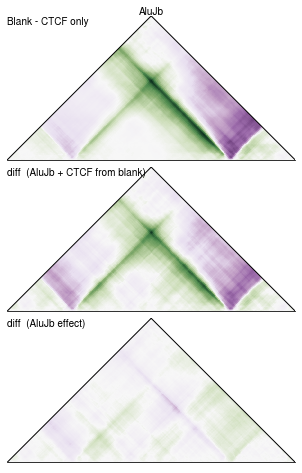

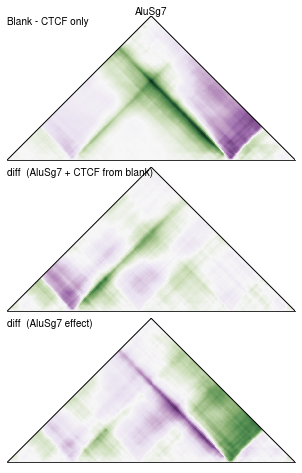

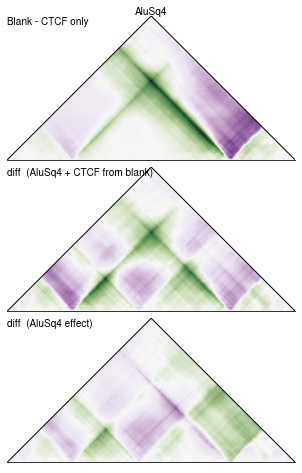

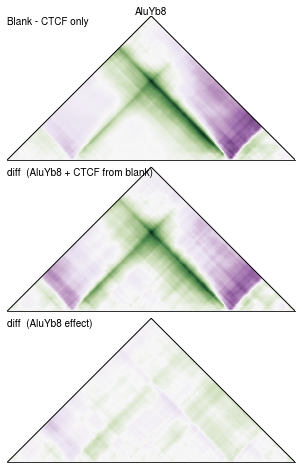

    alu distance 50000


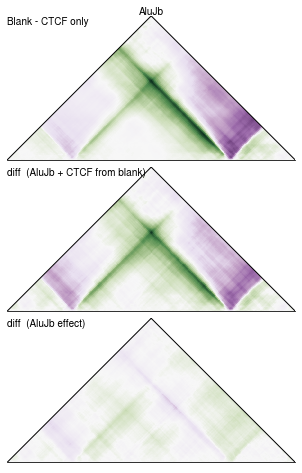

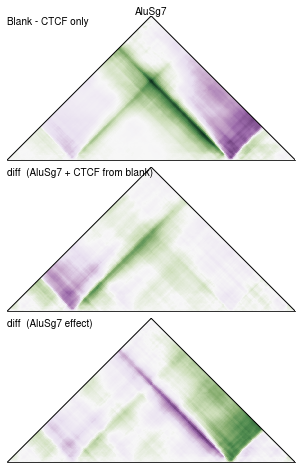

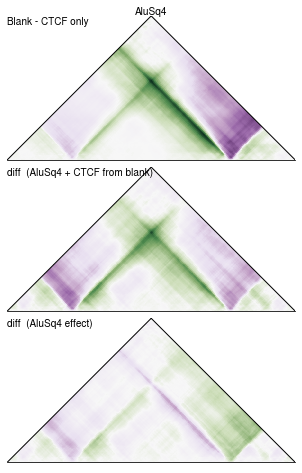

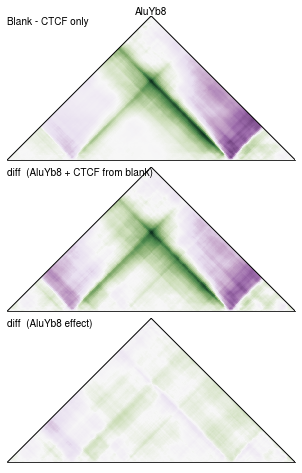

    alu distance 100000



KeyboardInterrupt



In [163]:
cleanseq_pred = akita.vector_from_seq(clean_seq)
cleanseq_map  = akita.map_from_vector(cleanseq_pred)


ctcf_only_seq, _, _ = insert_inverted_ctcf_pair(clean_seq, ctcf_pwm_freq, 
                                                distance_from_center=ctcf_dist_center, num_CTCF=num_CTCF)
ctcf_only_pred = akita.vector_from_seq(ctcf_only_seq)
ctcf_only_map  = akita.map_from_vector(ctcf_only_pred)


print("inserting alus ... ")

for alu_dist_center in alu_dist_center_list:
    print(f'    alu distance {alu_dist_center}')
#     results = insert_all_alus_with_ctcf(clean_seq, alu_dfam_query, ctcf_pwm_freq,
#         alu_distance_from_center=alu_dist_center, ctcf_distance_from_center=ctcf_dist_center, 
#                                         revcomp_alu=False, num_CTCF=num_CTCF)
    
    results=insert_two_alus_with_ctcf(clean_seq, alu_dfam_query, ctcf_pwm,
            alu_distance_from_center=alu_dist_center, ctcf_distance_from_center=ctcf_dist_center, 
            num_CTCF=num_CTCF, revcomp_left=False,revcomp_right=True)



    for r in results:
        panels = [
            #(ctcf_only_map,              'CTCF only',           cmap_pred, -2,    2),\
            (ctcf_only_map - cleanseq_map, 'CTCF only − blank', cmap_diff, -0.5, 0.5),
            #(r['map'],                   f"Alu {r['alu_name']} + CTCF",  cmap_pred, -2,    2),
            (r['map'] - cleanseq_map,   f"diff  ({r['alu_name']} + CTCF from blank)", cmap_diff, -0.5, 0.5),
            (r['map'] - ctcf_only_map,   f"diff  ({r['alu_name']} effect)", cmap_diff, -0.5, 0.5),

        ]

        lw, pw = 0.5, 2
        row_heights = []
        for _ in panels:
            row_heights += [pw, .1]
        row_heights = row_heights[:-1]
        fig, gs = gridspec_inches([pw * 2], row_heights)

        lines = [MB / 2]
        for ri, (mat, title, cm, vn, vx) in enumerate(panels):
            ax = plt.subplot(gs[ri * 2, 0])
            plotting_utils.pcolormesh_45deg(plt, mat, lines, lw, cmap=cm, vmax=vx, vmin=vn)
            ax.annotate(title, xy=(0, 0.9), xycoords='axes fraction',
                        xytext=(0, 4), textcoords='offset points',
                        ha='left', va='bottom', annotation_clip=False)

        fig.suptitle(f"{r['alu_name']}", y=1.02)
        plt.show()


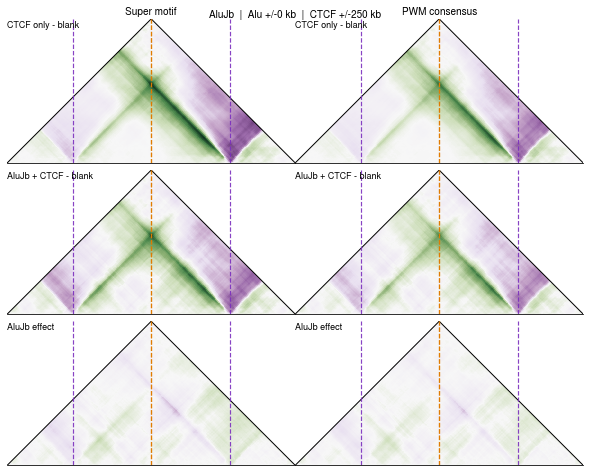

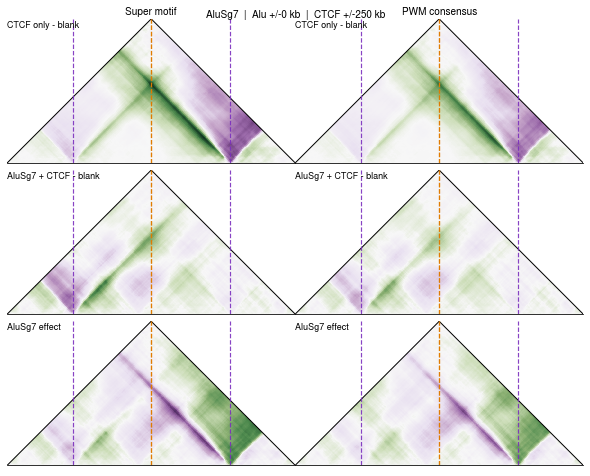

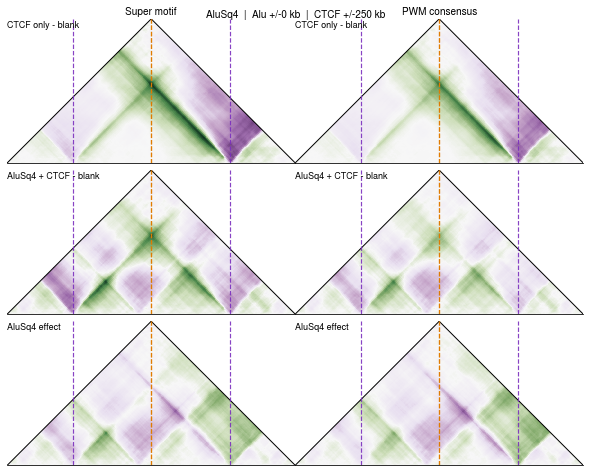

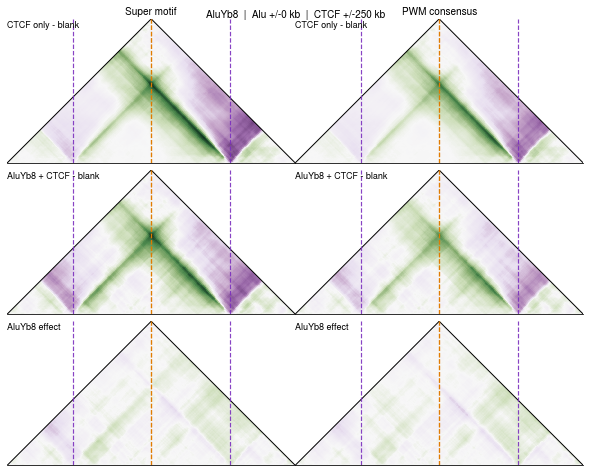

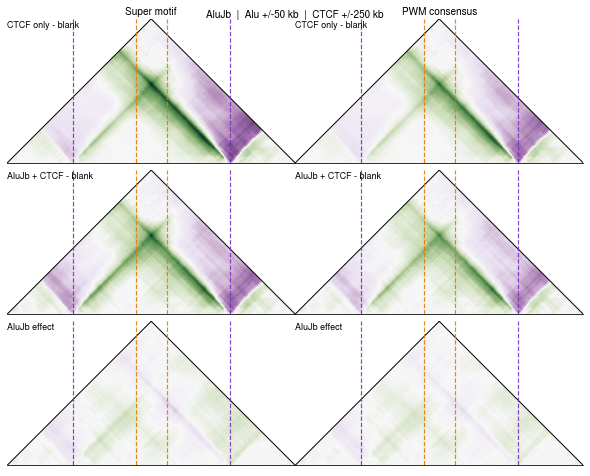

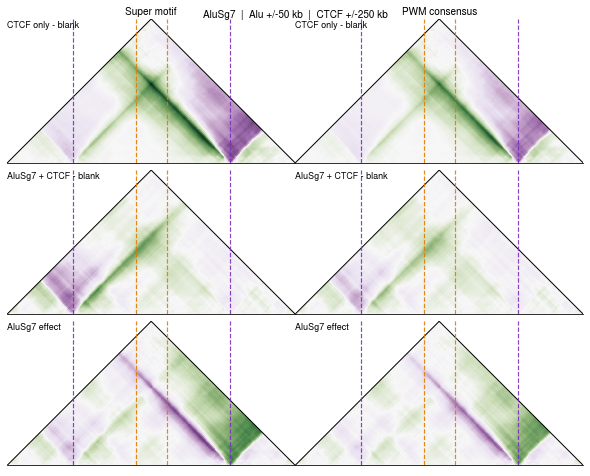

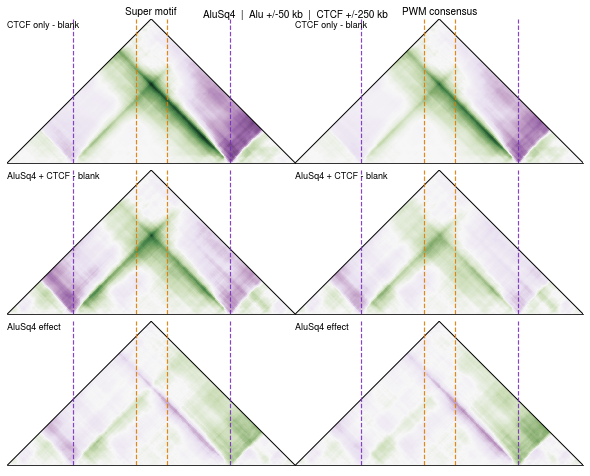

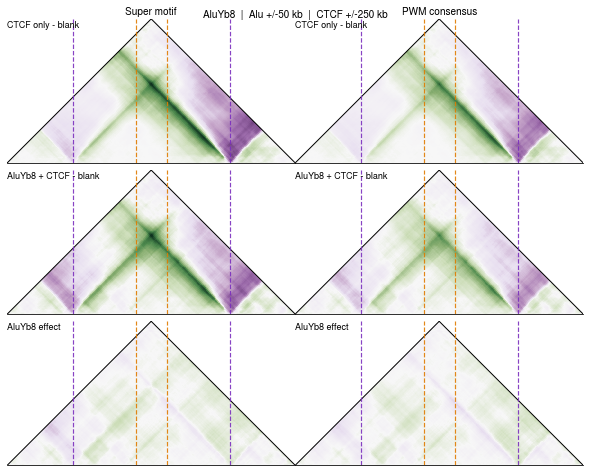

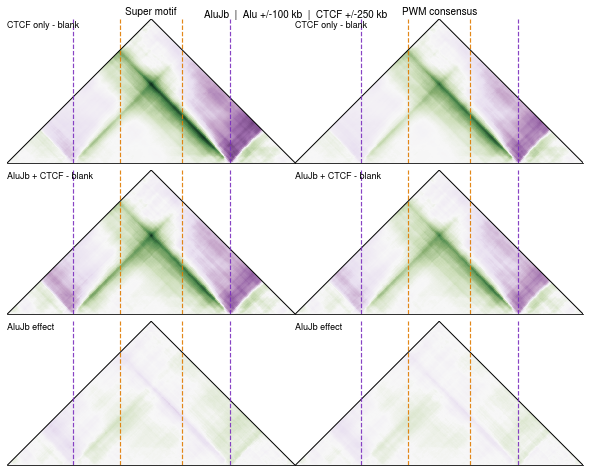

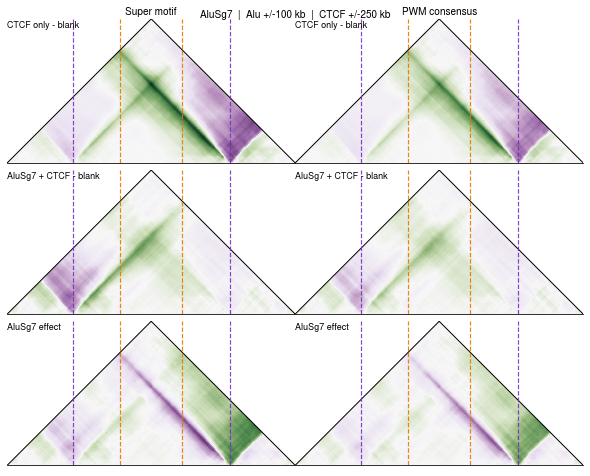

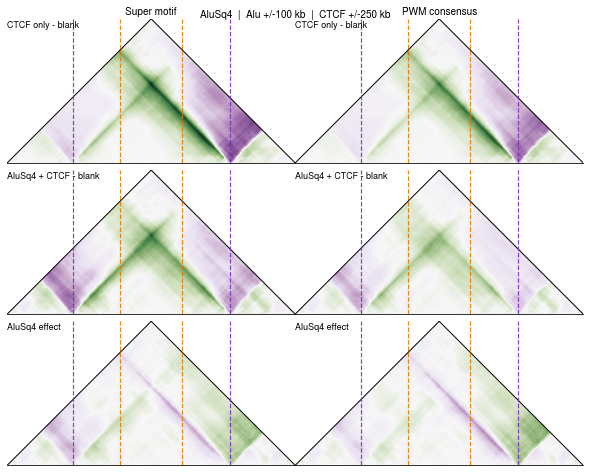

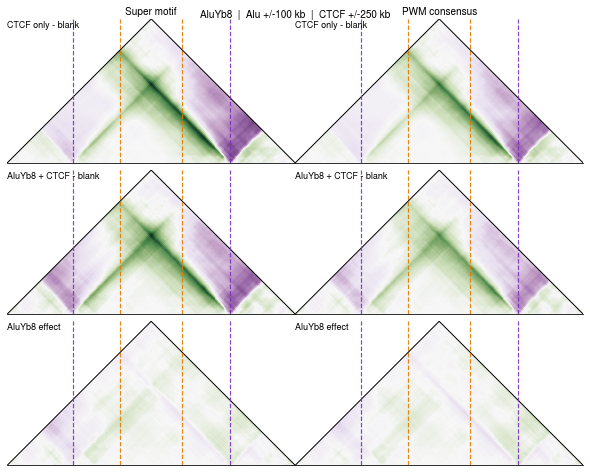

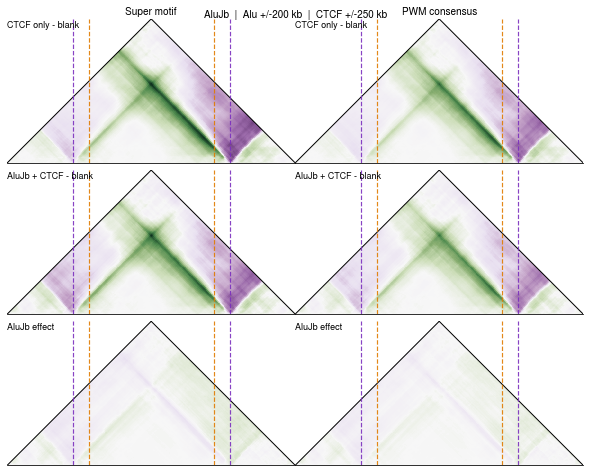

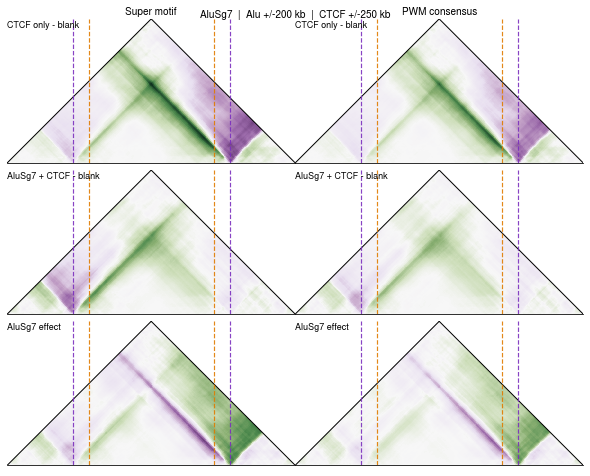

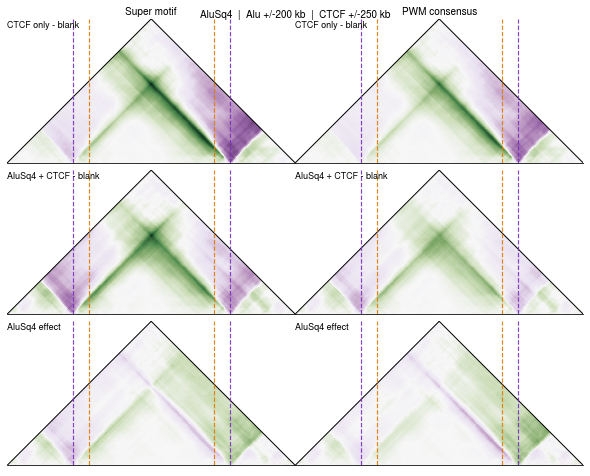

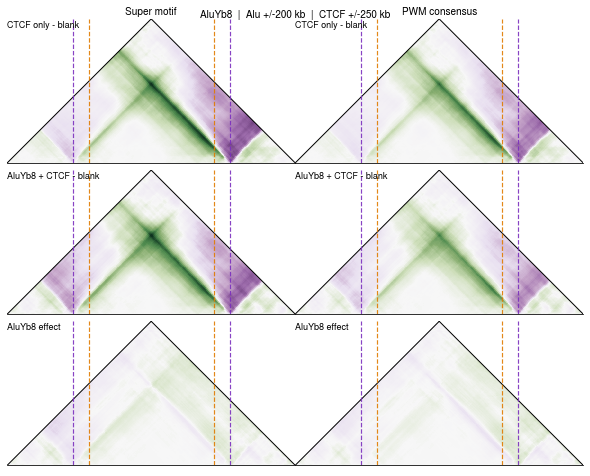

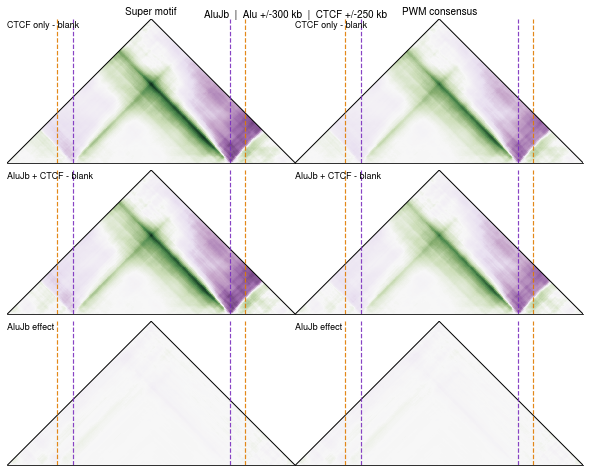

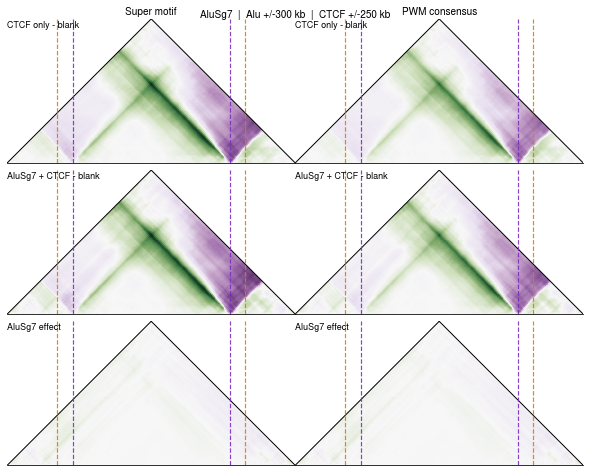

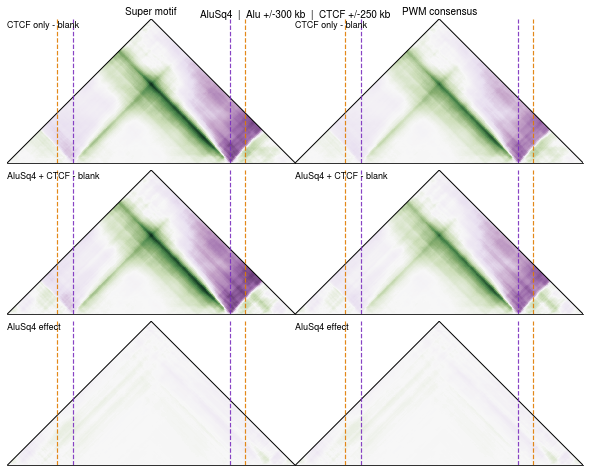

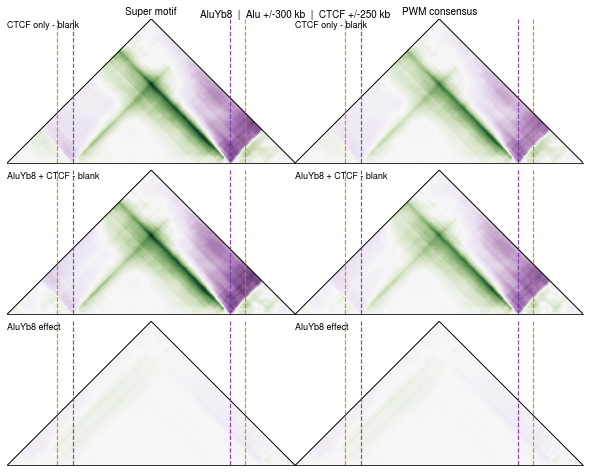

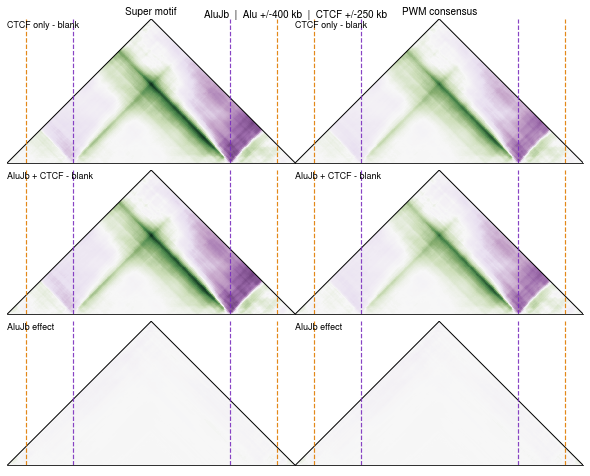

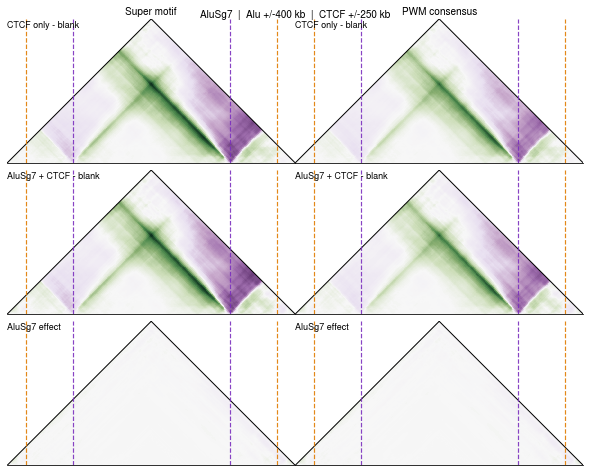

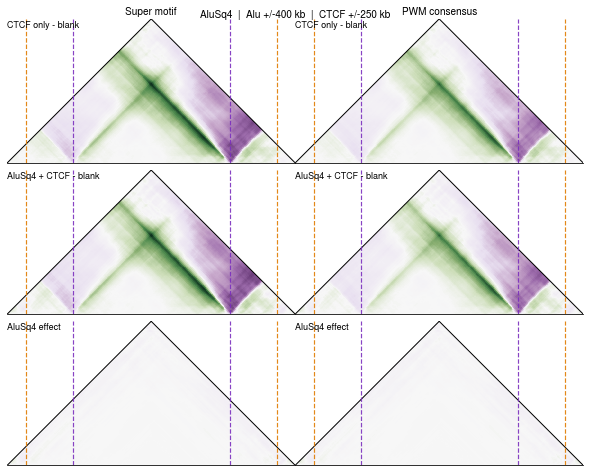

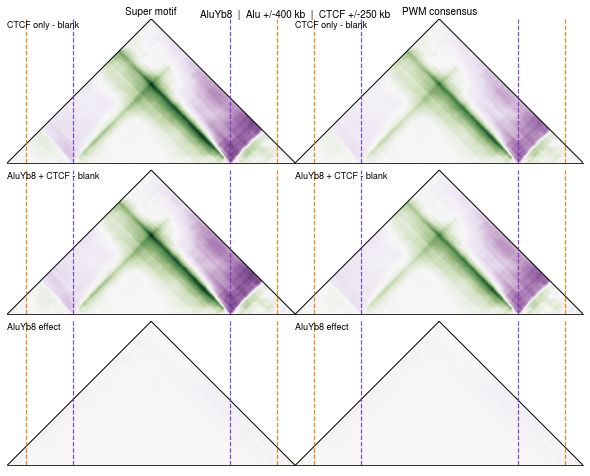

In [173]:
# two CTCF sequences to compare side-by-side
ctcf_seq_1 = 'TGGCCACTAGGTGGCGCCA'         # super motif (Laura et al.)
ctcf_seq_2 = get_pwm_consensus(ctcf_pwm_freq) # PWM consensus

# ctcf_seq_1 = str(Seq(ctcf_seq_1).reverse_complement())
# ctcf_seq_2 = str(Seq(ctcf_seq_2).reverse_complement())


ctcf_dist_center=250_000

for alu_dist_center in alu_dist_center_list:


    # baseline maps (no Alu) — one per CTCF sequence
    ctcf1_only_seq, _, _ = _insert_ctcf_pair_from_seq(clean_seq, ctcf_seq_1, ctcf_dist_center)
    ctcf2_only_seq, _, _ = _insert_ctcf_pair_from_seq(clean_seq, ctcf_seq_2, ctcf_dist_center)
    ctcf1_only_map = akita.map_from_vector(akita.vector_from_seq(ctcf1_only_seq))
    ctcf2_only_map = akita.map_from_vector(akita.vector_from_seq(ctcf2_only_seq))

    # run all Alu families with both CTCFs
    results = insert_two_alus_two_ctcfs(
        clean_seq, alu_dfam_query,
        ctcf_seq_1=ctcf_seq_1,
        ctcf_seq_2=ctcf_seq_2,
        alu_distance_from_center=alu_dist_center,
        ctcf_distance_from_center=ctcf_dist_center,
        revcomp_left=False, revcomp_right=True,  # convergent Alu pair
    )

    plot_two_alus_two_ctcfs(
        results, cleanseq_map, ctcf1_only_map, ctcf2_only_map,
        alu_distance_from_center=alu_dist_center,
        ctcf_distance_from_center=ctcf_dist_center,
        ctcf_label_1='Super motif', ctcf_label_2='PWM consensus',
        scale=1,
    )
